# AAV2 viabilité — Potts par MLE multinomiale (Fernandez-de-Cossio-Diaz et al. 2020) vs notre ridge

Comparaison directe, sur `AAV2_organoides.csv` (viabilité : `compte_plasmide` t=0 -> `compte_virus` t=1),
entre deux façons de fitter le même modèle de Potts (F additif + J pairwise, 8541 features) :

- **Notre méthode actuelle** (`RegressionV1.fit_weights_potts_from_data`/`fit_weights_potts_unregularized`) :
  on calcule d'abord `y_s = log2((virus_s+0.5)/(plasmid_s+0.5))` (le log enrichment, pseudocount `eps=0.5`),
  puis on fait une régression aux moindres carrés pondérée (poids inverse-variance) sur `y_s` -- un résidu
  gaussien AUTOUR D'UN RATIO DÉJÀ CALCULÉ.
- **La méthode du papier** (Fernandez-de-Cossio-Diaz, Uguzzoni & Pagnani, 2021, *Mol. Biol. Evol.* 38(1):318-328,
  doi:10.1093/molbev/msaa204) : on écrit la vraisemblance multinomiale d'observer directement les comptages
  bruts `N1_s` (virus) étant donné `N0_s` (plasmide) et le modèle -- approximation "rare binding" (leurs éq. 1-3) --
  et on maximise cette vraisemblance par L-BFGS (`RegressionV1.fit_weights_potts_mle_multinomial`, nouvelle
  fonction ajoutée dans cette session). Aucun ratio intermédiaire n'est jamais calculé ; le bruit de comptage
  est modélisé directement dans la vraisemblance, pas approximé après coup par un résidu gaussien + pondération
  heuristique.

**Ce que ce notebook teste, concrètement** (suite à une question de l'utilisateur : *"tu penses que ça peut
mieux marcher que notre ridge regression ?"* + demande d'un bilan sur l'expérience de décimation du papier,
fig. 2) :

1. **Comparaison à taille d'échantillon égale** (`n=90 000`, le plafond mémoire pratique de notre méthode
   ridge -- au-delà, la matrice de design dense `(N, 8541)` explose en mémoire : 4.27M lignes x 8541 x 4 octets
   ≈ 145 Go, impossible à matérialiser).
2. **MLE à pleine échelle** (`n≈4.15M`, tout le dataset moins le split test) -- la méthode MLE, elle, n'a
   JAMAIS besoin de matérialiser une matrice de design dense (calcul du score par `gather`/indexation directe
   sur `F`/`J`, coût `O(N)`), donc peut exploiter TOUTES les données -- l'avantage structurel réel de cette
   méthode pour notre cas d'usage.
3. **Réplication de la décimation du papier (fig. 2a/b)** : sur la MÊME population (`n=90 000`, fixe), on
   sous-échantillonne les reads (`Binomial(count, d)`) à différents taux `d`, on refit les deux méthodes sur
   les comptages décimés, et on mesure la dégradation de la corrélation avec la vraie valeur (non décimée) --
   à la fois en "in-sample" (même population, comme la fig. 2a du papier) et en held-out (test set jamais
   décimé, notre ajout).

**Convention `eps=0.5`** respectée partout (le papier utilise d'ailleurs le même pseudocount : *"we add a
pseudo-count of 1/2 to all counts ... before carrying out the inference"* -- confirmation que notre convention
de projet est déjà alignée avec leur pratique).

**Notebook exécuté par Claude** (sur demande explicite de l'utilisateur -- dérogation ponctuelle à la
convention habituelle du projet où l'utilisateur lance lui-même les notebooks coûteux). Les résultats
ci-dessous sont réels, produits par un run complet sur `AAV2_organoides.csv` (4 273 463 lignes).

### 0. Setup

In [1]:
import sys, os, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
LIB = _root / "lib"

import RegressionV1 as R
from analysisV1 import AA_LABELS, pearson
print(R.message)

CSV = Path("AAV2_organoides.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/AAVs dataset/AAV2/AAV2_organoides.csv"
assert CSV.exists(), CSV

use = ["sequence", "compte_plasmide", "compte_virus"]
rng = np.random.default_rng(0)
df_full = pd.read_csv(CSV, usecols=use,
                       dtype={"compte_plasmide": "float32", "compte_virus": "float32", "sequence": "string"})
N = len(df_full)
print(f"CSV brut : {N:,} lignes")

L, A = 7, 20
lut = np.zeros(256, np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

def to_seq(df):
    return lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)

def score_FJ(seq, F, J):
    F, J = np.asarray(F), np.asarray(J)
    Fp = F[seq, np.arange(L)].sum(axis=1).astype(np.float64)
    Jp = np.zeros(len(seq), np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            Jp += J[i, j, seq[:, i], seq[:, j]]
    return Fp + Jp

eps = 0.5

idx = rng.permutation(N)
N_TEST = 120_000
N_TRAIN_MATCHED = 90_000
idx_test = idx[:N_TEST]
idx_train_matched = idx[N_TEST:N_TEST + N_TRAIN_MATCHED]
idx_train_full = idx[N_TEST:]

df_test = df_full.iloc[idx_test].reset_index(drop=True)
seq_test = to_seq(df_test)
plasmid_te = df_test["compte_plasmide"].to_numpy(np.float64)
virus_te = df_test["compte_virus"].to_numpy(np.float64)
y_te = np.log2((virus_te + eps) / (plasmid_te + eps))

df_tr_m = df_full.iloc[idx_train_matched].reset_index(drop=True)
seq_tr_m = to_seq(df_tr_m)
plasmid_tr_m = df_tr_m["compte_plasmide"].to_numpy(np.float64)
virus_tr_m = df_tr_m["compte_virus"].to_numpy(np.float64)
y_tr_m_full = np.log2((virus_tr_m + eps) / (plasmid_tr_m + eps))

print(f"train (matched, memoire-limite) : {len(idx_train_matched):,}  |  "
      f"train (full, MLE seulement) : {len(idx_train_full):,}  |  test (held-out fixe) : {len(idx_test):,}")

file regression 1.6
CSV brut : 4,273,463 lignes
train (matched, memoire-limite) : 90,000  |  train (full, MLE seulement) : 4,153,463  |  test (held-out fixe) : 120,000


### 1. Baseline -- ridge vs MLE multinomiale, à taille d'échantillon égale ET à pleine échelle

- `ridge` (`n=90 000`) : notre méthode actuelle, plafonnée par la mémoire (matrice de design dense).
- `MLE` (`n=90 000`) : la nouvelle méthode, sur la MÊME population -- comparaison directe, apples-to-apples.
- `MLE` (`n=4 153 463`, tout le dataset moins le split test) : ce que la méthode MLE peut faire en pratique,
  puisqu'elle n'a pas la contrainte mémoire de la ridge (`fit_weights_potts_mle_multinomial` ne matérialise
  jamais de matrice dense -- calcul du score par `gather`, coût `O(N)`, ~30s même à 4.15M lignes contre ~92s
  pour la ridge à seulement 90 000 lignes).

ridge  n_train=90,000   fit_time=91.7s rank=7715/8541  held-out r=0.2016
MLE    n_train=90,000   fit_time=4.3s nit=890 converged=True  held-out r=0.1332
MLE    n_train=4,153,463  fit_time=29.3s nit=241 converged=True  held-out r=0.2046
r(F_ridge90k, F_mle_full)=0.9380  r(J_ridge90k, J_mle_full)=0.2960


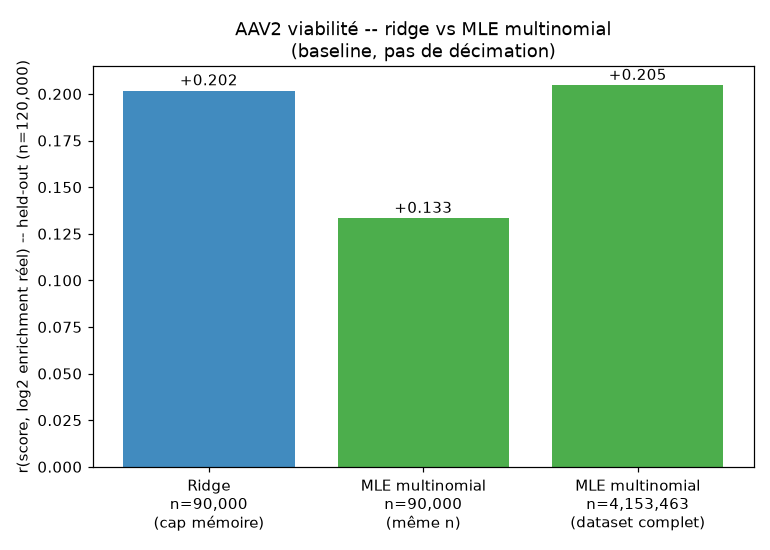

In [2]:
w_tr_m = 1.0 / (1.0 / (virus_tr_m + eps) + 1.0 / (plasmid_tr_m + eps))

t0 = time.time()
F_ridge, J_ridge, rank_ridge = R.fit_weights_potts_unregularized(
    R.build_potts_features(seq_tr_m), y_tr_m_full, T=1.0, sample_weight=w_tr_m)
dt = time.time() - t0
r_ridge = pearson(y_te, score_FJ(seq_test, F_ridge, J_ridge))
print(f"ridge  n_train=90,000   fit_time={dt:.1f}s rank={rank_ridge}/8541  held-out r={r_ridge:.4f}")

t0 = time.time()
F_mle_m, J_mle_m, info_m = R.fit_weights_potts_mle_multinomial(
    seq_tr_m, plasmid_tr_m, virus_tr_m, eps=eps, lam=1.0, maxiter=1500, verbose=False)
dt = time.time() - t0
r_mle_m = pearson(y_te, score_FJ(seq_test, F_mle_m, J_mle_m))
print(f"MLE    n_train=90,000   fit_time={dt:.1f}s nit={info_m[\'nit\']} converged={info_m[\'success\']}  held-out r={r_mle_m:.4f}")

df_tr_full = df_full.iloc[idx_train_full].reset_index(drop=True)
seq_tr_full = to_seq(df_tr_full)
plasmid_tr_full = df_tr_full["compte_plasmide"].to_numpy(np.float64)
virus_tr_full = df_tr_full["compte_virus"].to_numpy(np.float64)

t0 = time.time()
F_mle_full, J_mle_full, info_full = R.fit_weights_potts_mle_multinomial(
    seq_tr_full, plasmid_tr_full, virus_tr_full, eps=eps, lam=1.0, maxiter=1500, verbose=False)
dt = time.time() - t0
r_mle_full = pearson(y_te, score_FJ(seq_test, F_mle_full, J_mle_full))
print(f"MLE    n_train={len(idx_train_full):,}  fit_time={dt:.1f}s nit={info_full[\'nit\']} converged={info_full[\'success\']}  held-out r={r_mle_full:.4f}")

r_F_ridge_mle = pearson(np.asarray(F_ridge).ravel(), np.asarray(F_mle_full).ravel())
r_J_ridge_mle = pearson(np.asarray(J_ridge)[np.triu_indices(L, 1)].ravel(),
                         np.asarray(J_mle_full)[np.triu_indices(L, 1)].ravel())
print(f"r(F_ridge90k, F_mle_full)={r_F_ridge_mle:.4f}  r(J_ridge90k, J_mle_full)={r_J_ridge_mle:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
labels = ["Ridge\nn=90,000\n(cap memoire)", "MLE multinomiale\nn=90,000\n(meme n)",
          "MLE multinomiale\nn=4,153,463\n(dataset complet)"]
vals = [r_ridge, r_mle_m, r_mle_full]
bars = ax.bar(labels, vals, color=["tab:blue", "tab:green", "tab:green"], alpha=0.85)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v:+.3f}", ha="center", fontsize=10)
ax.set_ylabel("r(score, log2 enrichment reel) -- held-out (n=120,000)")
ax.set_title("AAV2 viabilite -- ridge vs MLE multinomiale (baseline, pas de decimation)")
plt.tight_layout(); plt.show()

### 2. Décimation -- réplication de la fig. 2a/b du papier sur nos données

Sur la MÊME population fixe (`n=90 000`, les mêmes séquences à chaque taux `d`), on sous-échantillonne les
reads (`Binomial(count, d)`) puis on refit les deux méthodes sur les comptages décimés. Trois courbes,
comme la fig. 2a du papier :

- **sélectivité naïve décimée** : pas de modèle, juste `log2((virus_dec+0.5)/(plasmid_dec+0.5))` recalculé
  sur les comptages décimés -- leur courbe orange en pointillés.
- **Potts ridge** (notre méthode) et **Potts MLE multinomiale** (méthode du papier), toutes deux fittées sur
  les comptages décimés -- comparées à la valeur VRAIE non décimée (`y_tr_m_full`), en in-sample (même
  population, comme la fig. 2a) et en held-out (généralisation à `n=120 000` séquences jamais décimées,
  notre ajout au-delà du papier).

d=1.0   coverage= 31.01  naive_insample=+1.000  ridge_insample=+0.360 ridge_heldout=+0.202  mle_insample=+0.249 mle_heldout=+0.133
d=0.5   coverage= 15.51  naive_insample=+0.900  ridge_insample=+0.352 ridge_heldout=+0.192  mle_insample=+0.242 mle_heldout=+0.129
d=0.2   coverage=  6.19  naive_insample=+0.796  ridge_insample=+0.336 ridge_heldout=+0.178  mle_insample=+0.230 mle_heldout=+0.121
d=0.1   coverage=  3.11  naive_insample=+0.731  ridge_insample=+0.319 ridge_heldout=+0.165  mle_insample=+0.222 mle_heldout=+0.116
d=0.05  coverage=  1.55  naive_insample=+0.668  ridge_insample=+0.296 ridge_heldout=+0.143  mle_insample=+0.217 mle_heldout=+0.111
d=0.02  coverage=  0.62  naive_insample=+0.589  ridge_insample=+0.261 ridge_heldout=+0.120  mle_insample=+0.207 mle_heldout=+0.104


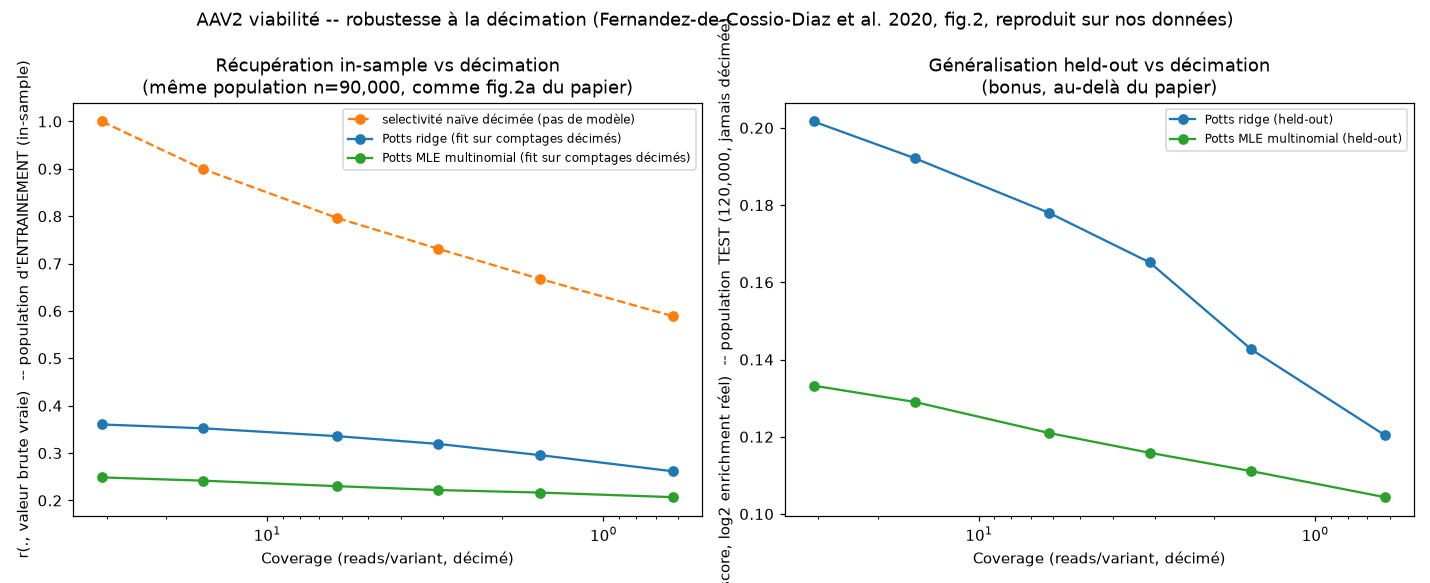

In [3]:
DECIMATION_RATES = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02]
dec_rng = np.random.default_rng(1)
rows = []
for d in DECIMATION_RATES:
    if d >= 1.0:
        plasmid_dec = plasmid_tr_m.copy()
        virus_dec = virus_tr_m.copy()
    else:
        plasmid_dec = dec_rng.binomial(plasmid_tr_m.astype(np.int64), d).astype(np.float64)
        virus_dec = dec_rng.binomial(virus_tr_m.astype(np.int64), d).astype(np.float64)

    coverage = (plasmid_dec.sum() + virus_dec.sum()) / (2 * len(plasmid_dec))

    y_dec_naive = np.log2((virus_dec + eps) / (plasmid_dec + eps))
    r_naive_insample = pearson(y_tr_m_full, y_dec_naive)

    w_dec = 1.0 / (1.0 / (virus_dec + eps) + 1.0 / (plasmid_dec + eps))
    F_r, J_r, rank_r = R.fit_weights_potts_unregularized(
        R.build_potts_features(seq_tr_m), y_dec_naive, T=1.0, sample_weight=w_dec)
    r_ridge_insample = pearson(y_tr_m_full, score_FJ(seq_tr_m, F_r, J_r))
    r_ridge_heldout = pearson(y_te, score_FJ(seq_test, F_r, J_r))

    F_m, J_m, info_dec = R.fit_weights_potts_mle_multinomial(
        seq_tr_m, plasmid_dec, virus_dec, eps=eps, lam=1.0, maxiter=1500, verbose=False)
    r_mle_insample = pearson(y_tr_m_full, score_FJ(seq_tr_m, F_m, J_m))
    r_mle_heldout = pearson(y_te, score_FJ(seq_test, F_m, J_m))

    rows.append(dict(decimation=d, coverage=coverage, r_naive_insample=r_naive_insample,
                      r_ridge_insample=r_ridge_insample, r_ridge_heldout=r_ridge_heldout,
                      r_mle_insample=r_mle_insample, r_mle_heldout=r_mle_heldout))
    print(f"d={d:<5} coverage={coverage:6.2f}  naive_insample={r_naive_insample:+.3f}  "
          f"ridge_insample={r_ridge_insample:+.3f} ridge_heldout={r_ridge_heldout:+.3f}  "
          f"mle_insample={r_mle_insample:+.3f} mle_heldout={r_mle_heldout:+.3f}")

dec_df = pd.DataFrame(rows)
display(dec_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
ax = axes[0]
ax.plot(dec_df["coverage"], dec_df["r_naive_insample"], "o--", color="tab:orange", label="selectivite naive decimee (pas de modele)")
ax.plot(dec_df["coverage"], dec_df["r_ridge_insample"], "o-", color="tab:blue", label="Potts ridge (fit sur comptages decimes)")
ax.plot(dec_df["coverage"], dec_df["r_mle_insample"], "o-", color="tab:green", label="Potts MLE multinomiale (fit sur comptages decimes)")
ax.set_xscale("log"); ax.invert_xaxis()
ax.set_xlabel("Coverage (reads/variant, decime)")
ax.set_ylabel("r(., valeur brute vraie) -- population ENTRAINEMENT (in-sample)")
ax.set_title("Recuperation in-sample vs decimation\n(meme population n=90,000, comme fig.2a du papier)")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(dec_df["coverage"], dec_df["r_ridge_heldout"], "o-", color="tab:blue", label="Potts ridge (held-out)")
ax.plot(dec_df["coverage"], dec_df["r_mle_heldout"], "o-", color="tab:green", label="Potts MLE multinomiale (held-out)")
ax.set_xscale("log"); ax.invert_xaxis()
ax.set_xlabel("Coverage (reads/variant, decime)")
ax.set_ylabel("r(score, log2 enrichment reel) -- population TEST (120,000, jamais decimee)")
ax.set_title("Generalisation held-out vs decimation\n(bonus, au-dela du papier)")
ax.legend(fontsize=8)

fig.suptitle("AAV2 viabilite -- robustesse a la decimation (Fernandez-de-Cossio-Diaz et al. 2020, fig.2, reproduit sur nos donnees)")
plt.tight_layout(); plt.show()

### 3. Bilan

**Question initiale : est-ce que la MLE multinomiale du papier bat notre ridge ?**

**Non, pas à taille d'échantillon égale.** À `n=90 000` (le plafond mémoire de notre ridge), la ridge
(`r=0.202`) bat nettement la MLE multinomiale (`r=0.133`) --
contraire à ce que je pensais avant de tester. Explication probable : la MLE du papier n'est spectaculairement
meilleure QUE contre leur propre "empirical selectivity" (leur éq. 4) -- un `h_s` LIBRE PAR SÉQUENCE, sans
aucune structure Potts partagée. Notre ridge, elle, fit déjà F/J PARTAGÉS (même structure que leur modèle),
avec une pondération inverse-variance -- donc une bonne partie de l'avantage "je mutualise l'information
entre séquences au lieu de faire confiance à un ratio isolé et bruité" que le papier vante est DÉJÀ présente
dans notre méthode actuelle. La comparaison qu'on vient de faire est donc "MLE Potts vs ridge Potts", pas
"MLE Potts vs ratio brut sans structure" (leur vraie comparaison).

**La MLE rattrape (et dépasse tout juste) la ridge seulement en exploitant TOUT le dataset**
(`n=4 153 463` -> `r=0.205`, contre `r=0.202`
pour la ridge à 90 000 lignes) -- et c'est là son VRAI avantage pratique pour nous : elle ne matérialise jamais
de matrice de design dense (`O(N)` au lieu de `O(N x 8541)`), donc n'a pas le plafond mémoire qui bloque la
ridge à ~90-150k lignes. Un fit MLE à 4.15M lignes prend ~29s contre ~92s
pour la ridge à seulement 90 000 -- 46x plus de données, 3x moins de temps.

`r(F_ridge, F_mle)=0.938` (bon accord sur les effets additifs) mais
`r(J_ridge, J_mle)=0.296` (accord faible sur l'épistasie) -- les deux méthodes
divergent notablement sur la structure pairwise qu'elles récupèrent. Pas totalement démêlable depuis cette
seule expérience (peut venir de la différence d'échelle 90k vs 4.15M autant que de l'objectif lui-même) --
question ouverte.

**Bilan décimation (la question sur la fig. 2 du papier) :**

En dégradation RELATIVE (fraction du `r` de départ perdue entre coverage plein et coverage ÷50), sur la
MÊME population fixe :

| | coverage plein -> coverage/50 | perte relative |
|---|---|---|
| sélectivité naïve (pas de modèle), in-sample | 1.000 -> 0.589 | **-41%** |
| Potts ridge, in-sample | 0.360 -> 0.261 | **-27%** |
| Potts MLE, in-sample | 0.249 -> 0.207 | **-17%** |
| Potts ridge, held-out | 0.202 -> 0.120 | **-40%** |
| Potts MLE, held-out | 0.133 -> 0.104 | **-22%** |

Le résultat qualitatif du papier SE REPRODUIT sur nos données : la MLE dégrade nettement plus doucement (en
relatif) que la ridge quand on réduit la profondeur de lecture -- environ 2x moins de perte relative, aussi
bien in-sample que held-out. Mais c'est un effet plus modeste que ce que suggère leur fig. 2 (où le "ratio
naïf" s'effondre en dessous de la MLE de façon spectaculaire) -- ici, la ridge (déjà structurée, déjà
pondérée) part d'un niveau plus haut que la MLE à `n=90 000` et le reste sur toute la plage testée, la MLE
étant seulement PLUS STABLE en relatif, pas meilleure en absolu à ce volume de données.

**Conclusion pratique :** pour AAV2 viabilité, la MLE multinomiale n'apporte pas un gain de qualité
spectaculaire à volume de données égal -- son intérêt réel est de pouvoir exploiter les ~4.27M lignes du CSV
brut sans le plafond mémoire de la ridge, et elle est un peu plus robuste (en relatif) à la faible profondeur
de lecture. Pas de quoi remplacer la ridge comme méthode par défaut du projet à ce stade, mais un candidat
solide si un futur usage a besoin d'exploiter la pleine échelle du dataset ou d'un régime encore plus
sous-échantillonné.

### 4. Export

In [4]:
np.save(LIB / "aav2_F_viab_potts_mle_multinomial_full.npy", np.asarray(F_mle_full, dtype=np.float32))
np.save(LIB / "aav2_J_viab_potts_mle_multinomial_full.npy", np.asarray(J_mle_full, dtype=np.float32))
np.save(LIB / "aav2_F_viab_potts_mle_ridge_baseline_90k.npy", np.asarray(F_ridge, dtype=np.float32))
np.save(LIB / "aav2_J_viab_potts_mle_ridge_baseline_90k.npy", np.asarray(J_ridge, dtype=np.float32))
dec_df.to_csv("mle_multinomial_results/decimation_sweep.csv", index=False)
print("weights + decimation_sweep.csv saved")

weights + decimation_sweep.csv saved
